# 01. ベイズの定理と確率の直感 — 事前確率を無視するな

## この章で分かること

- 条件付き確率と **ベイズの定理** の導出
- 医療検査の **陽性的中率** — 直感が大きく外れる代表例
- スパム判定 — ベイズの定理の最初の実用例
- **事前確率(基準率)** がなぜ決定的に重要か

## 1. 条件付き確率 — 「分かったこと」で世界を絞る

条件付き確率は「B が起きたと分かった世界の中で、A が起きている割合」です。

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

これを 2 通りに書いて等置すると($P(A \cap B) = P(B \mid A)P(A) = P(A \mid B)P(B)$)、
**ベイズの定理** が出ます。

$$
P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}
$$

意味: **「A → B の知識」から「B → A の推論」を作る変換器**。
原因 A と結果 B について、「原因があるとき結果が出る確率」は実験で測れますが、
実務で欲しいのは「結果を見たとき原因がある確率」。その橋渡しがこの定理です。

In [1]:
# Shared setup.
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio

from bayes_textbook import visualization as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 2. Problem — 医療検査のパラドックス

ある病気の検査を考えます。

- 有病率(事前確率): 1%(1000 人に 10 人)
- 感度: 95%(病気の人を正しく陽性にする確率)
- 特異度: 95%(健康な人を正しく陰性にする確率)

**「あなたは陽性でした」— 本当に病気である確率はいくつでしょう?**

多くの人は 90% 前後と答えますが、正解は約 **16%** です。
ベイズの定理で確かめます。$D$ = 病気、$+$ = 陽性として:

$$
P(D \mid +) = \frac{P(+ \mid D)\, P(D)}{P(+ \mid D)P(D) + P(+ \mid \bar{D})P(\bar{D})}
$$

In [2]:
# Positive predictive value by Bayes' theorem.
prevalence, sensitivity, specificity = 0.01, 0.95, 0.95

p_pos = sensitivity * prevalence + (1 - specificity) * (1 - prevalence)
ppv = sensitivity * prevalence / p_pos
print(f"P(disease | positive) = {ppv:.3f}   (prior was {prevalence})")

P(disease | positive) = 0.161   (prior was 0.01)


## 3. Intuition — 自然頻度で考える

確率のままだと直感が働きません。**1 万人の集団** に翻訳すると一目瞭然です。

- 病気: 100 人 → 陽性 95 人(真陽性)
- 健康: 9,900 人 → 陽性 495 人(偽陽性)

陽性者 590 人のうち本当に病気なのは 95 人 — だから $95/590 \approx 16\%$。
**健康な人が圧倒的に多いので、5% の偽陽性率でも偽陽性の「人数」が真陽性を圧倒する**。
これが事前確率(基準率)の威力です。

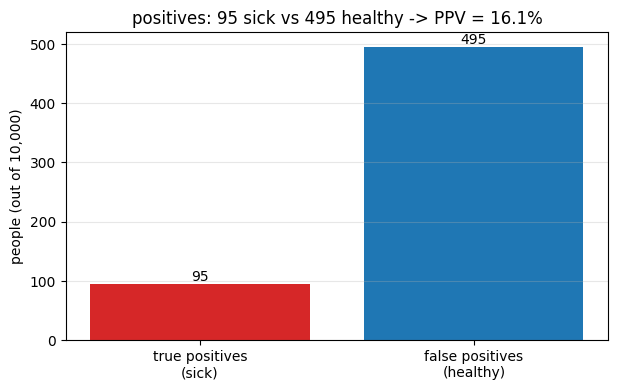

In [3]:
# Natural frequencies: the same calculation as counts out of 10,000 people.
n = 10_000
sick = int(prevalence * n)
tp = sensitivity * sick
fp = (1 - specificity) * (n - sick)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["true positives\n(sick)", "false positives\n(healthy)"], [tp, fp],
       color=["#d62728", "#1f77b4"])
for i, v in enumerate([tp, fp]):
    ax.text(i, v + 5, f"{v:.0f}", ha="center")
ax.set_ylabel("people (out of 10,000)")
ax.set_title(f"positives: {tp:.0f} sick vs {fp:.0f} healthy -> PPV = {ppv:.1%}")
ax.grid(alpha=0.3, axis="y")
plt.show()

## 4. Visualization — 有病率で PPV はどう動くか

PPV は有病率に強烈に依存します。下の Plotly スライダーで感度・特異度を変えながら、
**有病率 → PPV** の曲線を観察してください(静的 HTML でも動きます)。

- 有病率が低いほど、同じ検査でも PPV は急落する
- 特異度の改善は、低有病率域で感度の改善よりはるかに効く

In [4]:
# PPV vs prevalence, with a slider over (sensitivity, specificity) pairs.
prev_grid = np.logspace(-4, np.log10(0.5), 120)


def ppv_curve(sens, spec):
    return sens * prev_grid / (sens * prev_grid + (1 - spec) * (1 - prev_grid))


frames = []
for sens, spec in [(0.99, 0.90), (0.95, 0.95), (0.90, 0.99), (0.99, 0.99)]:
    frames.append((f"sens={sens}, spec={spec}",
                   [("PPV", ppv_curve(sens, spec), None),
                    ("prior (no test)", prev_grid, "dash")]))

fig = viz.plotly_curve_slider(prev_grid, frames, slider_name="test quality",
                              title="P(disease | positive) vs prevalence", ylim=(0, 1.02))
fig.update_xaxes(type="log", title="prevalence (log scale)")
fig.update_yaxes(title="probability")
fig.show()

### インタラクティブ(JupyterLab のみ)

3 つのスライダーで有病率・感度・特異度を動かすデモです。静的 HTML では上の図を参照。

In [5]:
# Interactive (JupyterLab only): sliders for prevalence / sensitivity / specificity.
from bayes_textbook.widgets import interactive_medical_test

interactive_medical_test()

interactive(children=(FloatSlider(value=0.01, description='prevalence', max=0.5, min=0.001, readout_format='.3…

<function bayes_textbook.widgets.interactive_medical_test.<locals>.draw(prevalence, sensitivity, specificity)>

## 5. シミュレーションで検算する

ベイズの定理の答えは、モンテカルロでそのまま確かめられます。
1 千万人を乱数で作り、「陽性だった人のうち病気の割合」を数えるだけです。

In [6]:
# Monte Carlo check of the analytic PPV.
n_sim = 10_000_000
is_sick = rng.random(n_sim) < prevalence
test_pos = np.where(is_sick,
                    rng.random(n_sim) < sensitivity,
                    rng.random(n_sim) < (1 - specificity))
mc_ppv = is_sick[test_pos].mean()
print(f"Monte Carlo PPV = {mc_ppv:.4f}   analytic = {ppv:.4f}")

Monte Carlo PPV = 0.1611   analytic = 0.1610


## 6. スパム判定 — 単語からメールを推論する

ベイズの定理の古典的応用です。$S$ = スパム、$w$ = 「無料」という単語の出現として:

$$
P(S \mid w) = \frac{P(w \mid S)\, P(S)}{P(w \mid S)P(S) + P(w \mid \bar{S})P(\bar{S})}
$$

複数の単語は(条件付き独立を仮定して)尤度を掛け合わせていきます —
これが **ナイーブベイズ分類器** です。単語を見るたびに信念が更新されていく様子を見ます。

In [7]:
# Naive Bayes spam scoring: belief updates word by word.
p_spam = 0.4                       # prior: 40% of mail is spam
# P(word | spam), P(word | ham) for a tiny vocabulary.
word_probs = {
    "free":    (0.30, 0.02),
    "meeting": (0.01, 0.15),
    "winner":  (0.20, 0.01),
    "report":  (0.02, 0.20),
}


def update_spam_belief(words, p_spam0=p_spam):
    odds = p_spam0 / (1 - p_spam0)
    trail = [p_spam0]
    for w in words:
        p_w_spam, p_w_ham = word_probs[w]
        odds *= p_w_spam / p_w_ham          # multiply by the likelihood ratio
        trail.append(odds / (1 + odds))
    return trail


for words in [["free", "winner"], ["meeting", "report"], ["free", "meeting"]]:
    trail = update_spam_belief(words)
    path = " -> ".join(f"{p:.2f}" for p in trail)
    print(f"{str(words):28s}: P(spam) {path}")

['free', 'winner']          : P(spam) 0.40 -> 0.91 -> 1.00
['meeting', 'report']       : P(spam) 0.40 -> 0.04 -> 0.00
['free', 'meeting']         : P(spam) 0.40 -> 0.91 -> 0.40


単語 1 つごとに **オッズ × 尤度比** で信念が動きます。
「free」で跳ね上がり、「meeting」で引き戻される — まさに逐次的なベイズ更新です。

## 7. Failure Mode — 事前確率の無視(基準率の錯誤)

検査の例で人が 90% と答えてしまうのは、**$P(+ \mid D)$ と $P(D \mid +)$ を取り違える** からです
(検察官の誤謬とも呼ばれます)。ベイズの定理は、この 2 つを事前確率で橋渡しします。

- 事前確率を無視する → 稀な事象を大幅に過大評価
- 尤度だけで判断する → 「検査が当たる確率 95%」に引きずられる
- 対策はひとつ: **必ず事前確率(基準率)を掛ける**

逆に、事前確率が極端すぎると、どれだけデータを見ても信念が動かなくなります
($P(A) = 0$ なら事後も常に 0)。事前分布の選び方は 03〜04 章の主題です。

## 8. まとめ

- ベイズの定理は「原因→結果」の知識を「結果→原因」の推論に変える変換器。
- **事前確率(基準率)を掛け忘れると推論は大きく外れる**(医療検査で 90% → 16%)。
- 自然頻度(1 万人中何人)に翻訳すると直感が働く。
- 逐次更新は「オッズ × 尤度比」の繰り返し(スパム判定)。
- 次章から「確率」が「確率分布」になり、同じ定理が分布の更新になります。

## 9. Exercises

1. 有病率 0.1%・感度 99%・特異度 99% のとき PPV を手計算し、コードで検算せよ。
2. 同じ検査を **2 回** 受けて 2 回とも陽性だったときの病気の確率を求めよ
   (1 回目の事後を 2 回目の事前にする。検査は独立と仮定)。
3. 自然頻度の棒グラフを「有病率 20%」で描き直し、PPV がどう変わるか確認せよ。
4. スパム判定で `["winner", "report", "free"]` の信念の軌跡を計算せよ。
   単語の順番を入れ替えると最終結果は変わるか?
5. (発展)モンテカルロ検算を有病率 0.01% で行うと精度が落ちる。なぜか。
   陽性者の数に注目して説明せよ。